In [ ]:
from google.colab import files
import pandas as pd
import io
import numpy as np

# 1. Upload the File
print("Click 'Choose Files' and select the .lst file:")
uploaded = files.upload()

if not uploaded:
    print("No file selected. Please run the cell again!")
else:
    # 2. Load file into dataframe
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=r'\s+', header=None)

    # 3. Define column names according to .fmt guide
    column_names = [
        'Year', 'DOY', 'Hour', 'B', 'Bz', 'T', 'N', 'V', 'P', 'Kp_x10', 'R', 'Dst'
    ]
    df.columns = column_names

    # 4. Data cleaning (NASA missing values: 999.9, 999, etc.)
    df = df.replace([999.9, 9999, 99.9, 999999.0, 999, 0.999], np.nan)

    # 5. Kp correction (from 0-90 scale to 0-9)
    df['Kp'] = df['Kp_x10'] / 10

    # 6. Create clean dataset (remove rows with NaN)
    df_clean = df.dropna().copy()

    # 7. Print results
    print(f"\nFile '{filename}' processed successfully!")
    print("-" * 40)
    print(f"Initial rows: {len(df)}")
    print(f"Clean rows (no missing values): {len(df_clean)}")
    print("-" * 40)
    print("Data sample (first 5 rows):")
    display(df_clean[['Year', 'DOY', 'Hour', 'Bz', 'V', 'Kp', 'Dst']].head())

    print(f"Total initial rows: {len(df)}")
    print(f"Total clean rows: {len(df_clean)}")

Click 'Choose Files' and select the .lst file:


Saving solar_data.txt to solar_data.txt

File 'solar_data.txt' processed successfully!
----------------------------------------
Initial rows: 196512
Clean rows (no missing values): 191568
----------------------------------------
Data sample (first 5 rows):


,Year,DOY,Hour,Bz,V,Kp,Dst
0,1997,213,0,1.3,419.0,1.7,-8
1,1997,213,1,0.8,421.0,1.7,-6
2,1997,213,2,0.6,438.0,1.7,-10
3,1997,213,3,0.1,426.0,2.0,-14
4,1997,213,4,0.4,427.0,2.0,-15


Total initial rows: 196512
Total clean rows: 191568


In [ ]:
# 1. Finding the first and last recorded date in the clean dataset
first_row = df_clean.iloc[0]
last_row = df_clean.iloc[-1]

print(f"First recorded time: Year {int(first_row['Year'])}, Day (DOY) {int(first_row['DOY'])}, Hour {int(first_row['Hour'])}")
print(f"Last recorded time: Year {int(last_row['Year'])}, Day (DOY) {int(last_row['DOY'])}, Hour {int(last_row['Hour'])}")


# 2. Calculating the total data range
total_years = df_clean['Year'].max() - df_clean['Year'].min()
print(f"Total data range: {total_years} years")

First recorded time: Year 1997, Day (DOY) 213, Hour 0
Last recorded time: Year 2019, Day (DOY) 365, Hour 23
Total data range: 22 years


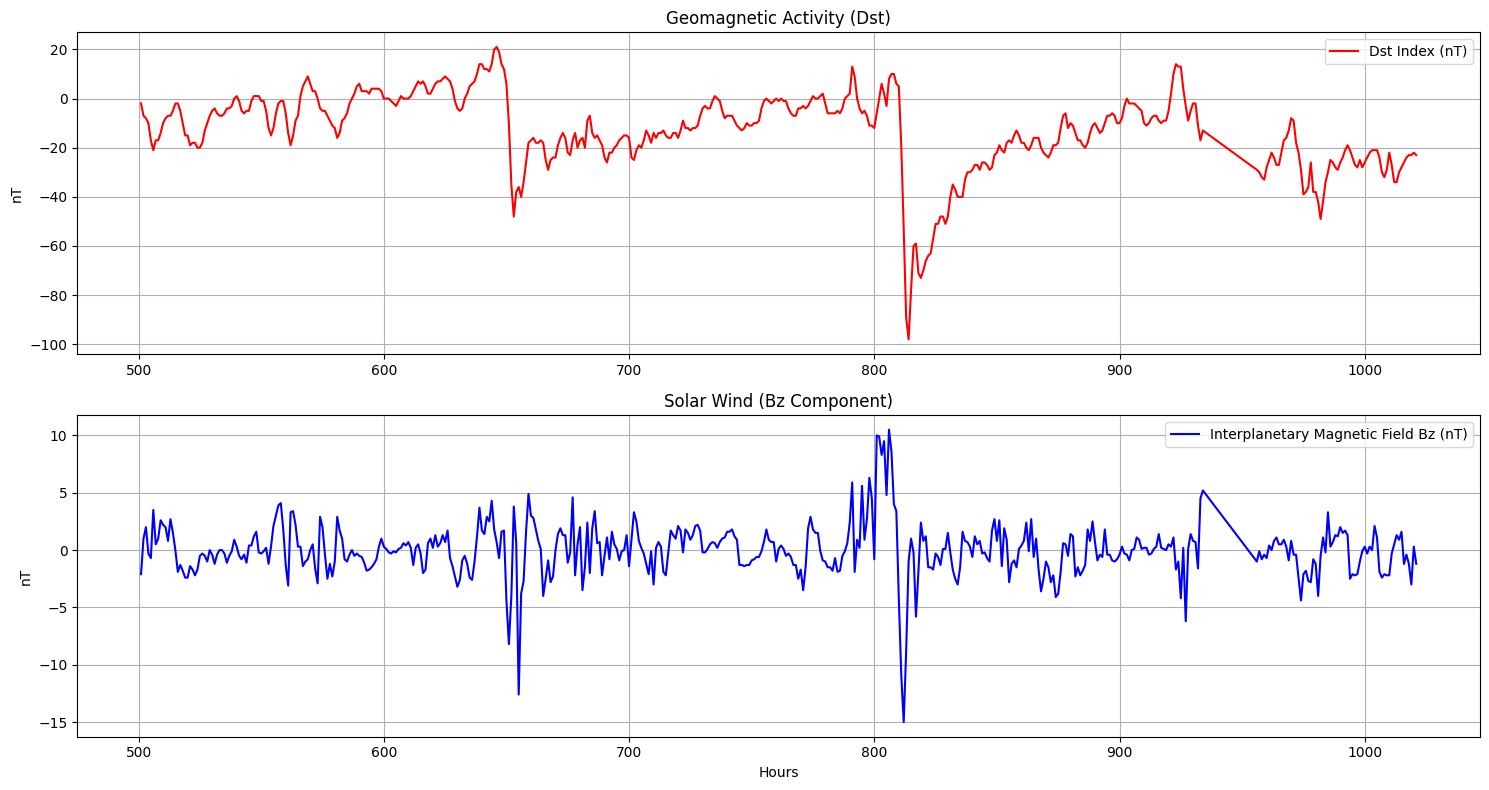

In [ ]:
import matplotlib.pyplot as plt

# Selecting a representative sample of 500 hours for visualization.
# Preferably a period during a geomagnetic storm.
subset = df_clean.iloc[500:1000]

plt.figure(figsize=(15, 8))

# Plot 1: Dst Index (Target Variable)
plt.subplot(2, 1, 1)
plt.plot(subset['Dst'], color='red', label='Dst Index (nT)')
plt.title('Geomagnetic Activity (Dst)')
plt.ylabel('nT')
plt.grid(True)
plt.legend()

# Plot 2: Bz Component (Solar Wind Driver)
plt.subplot(2, 1, 2)
plt.plot(subset['Bz'], color='blue', label='Interplanetary Magnetic Field Bz (nT)')
plt.title('Solar Wind (Bz Component)')
plt.ylabel('nT')
plt.xlabel('Hours')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 1. Add 'Dst' to the list so the model knows the previous state
features_to_lag = ['B', 'Bz', 'T', 'N', 'V', 'P', 'Dst']

# 2. Create Lags for 1 and 2 hours back for all parameters
for col in features_to_lag:
    df_clean[f'{col}_lag1'] = df_clean[col].shift(1)
    df_clean[f'{col}_lag2'] = df_clean[col].shift(2)

# 3. Remove rows with NaN values created by the shift operation
df_final = df_clean.dropna().copy()


print(f"\nTotal records for training: {len(df_final)}")


Total records for training: 191566


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

#Feature Selection: Selecting only columns with _lag1 and _lag2
X = df_final[[col for col in df_final.columns if '_lag' in col]]
y = df_final['Dst']

# Split Data: 80% Train - 20% Test (shuffle=False for time-series data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model Creation and Training
# n_jobs=-1 uses all available CPU cores in Google Colab for faster training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training started... (this may take 1-2 minutes)")
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Calculate Evaluation Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*30)
print(f"MODEL RESULTS")
print("="*30)
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f} nT")
print("="*30)

Training started... (this may take 1-2 minutes)

MODEL RESULTS
R2 Score: 0.9579
RMSE: 3.22 nT


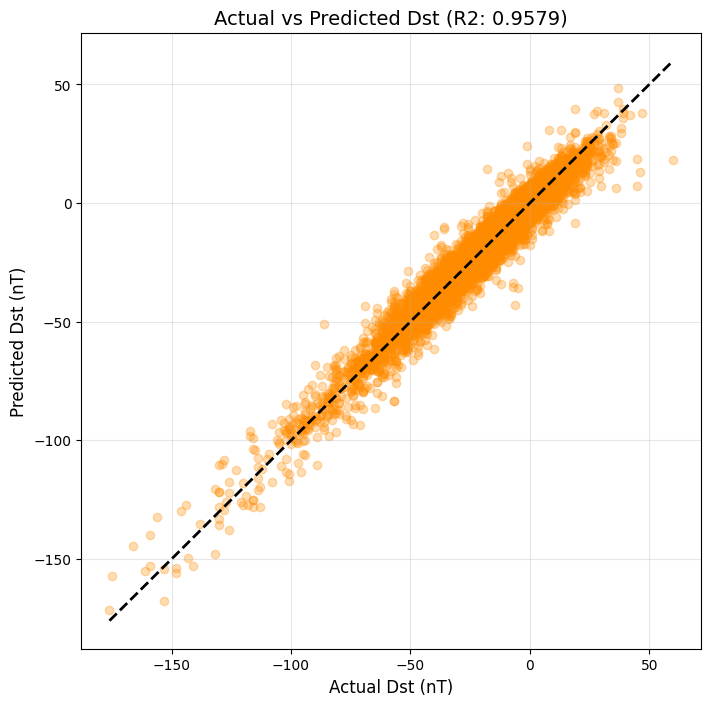

In [ ]:
import matplotlib.pyplot as plt

# Actual vs Predicted Dst Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f'Actual vs Predicted Dst (R2: 0.9579)', fontsize=14)
plt.xlabel('Actual Dst (nT)', fontsize=12)
plt.ylabel('Predicted Dst (nT)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

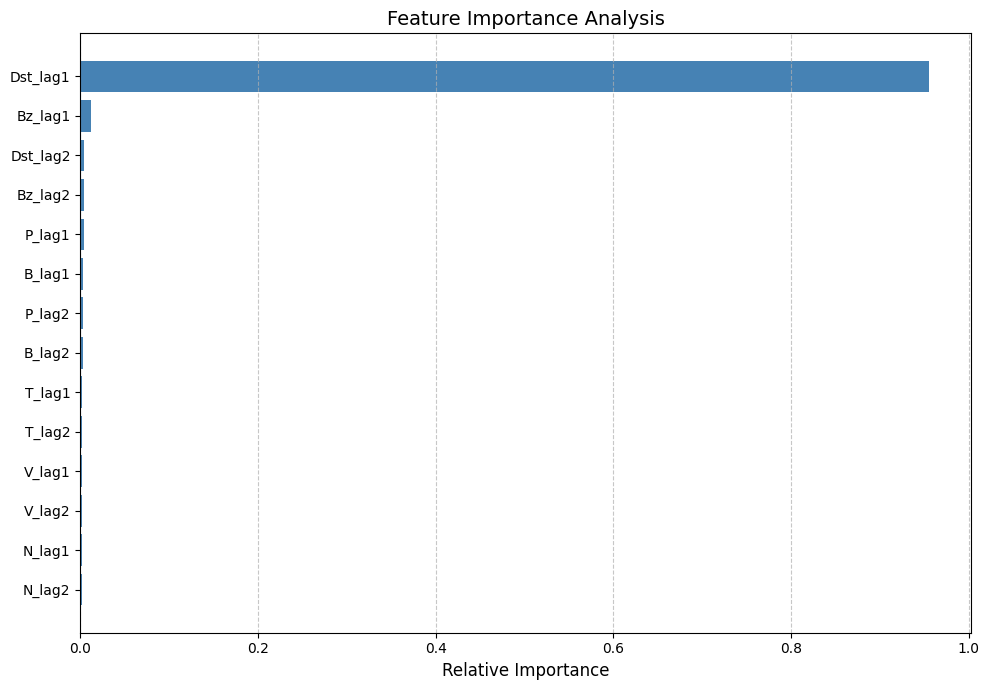

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extracting feature importances from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)

# Feature Importance Bar Chart
plt.figure(figsize=(10, 7))
plt.title('Feature Importance Analysis', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

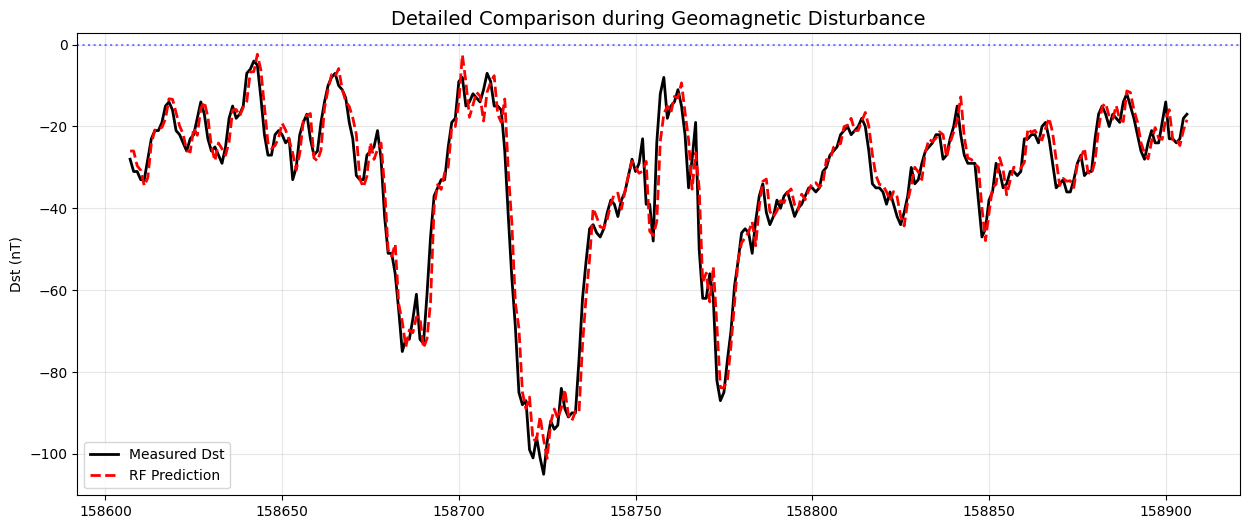

In [ ]:
# Create a DataFrame to align predictions with their dates
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index).sort_index()

# Selection of a 300-hour sample range for detail (e.g., from record 500 to 800)
# This interval is chosen to include a major geomagnetic storm
sample = results.iloc[500:800]

plt.figure(figsize=(15, 6))
plt.plot(sample['Actual'], label='Measured Dst', color='black', linewidth=2)
plt.plot(sample['Predicted'], label='RF Prediction', color='red', linestyle='--', linewidth=2)
plt.title('Detailed Comparison during Geomagnetic Disturbance', fontsize=14)
plt.ylabel('Dst (nT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='blue', linestyle=':', alpha=0.5)
plt.show()

In [ ]:
# Select a random prediction from the test set for testing
# Or you can manually define a value
test_index = 50  # Arbitrary row index
predicted_val = y_pred[test_index]

print(f"Model prediction for Dst index: {predicted_val:.2f} nT")
print("-" * 40)

# Classification based on Dst value thresholds
if predicted_val > -30:
    print("STATUS: Quiet")
elif -30 >= predicted_val > -50:
    print("STATUS: Weak Storm")
elif -50 >= predicted_val > -100:
    print("STATUS: Moderate Storm")
elif -100 >= predicted_val > -250:
    print("WARNING: Intense Storm")
else:
    print("ALERT: Superstorm")
print("-" * 40)

# Retrieving details for the specific test record (50th row)
timestamp_50 = X_test.index[50]
actual_val = y_test.iloc[50]
predicted_val = y_pred[50]

print(f"Test Set Record (Index 50): {timestamp_50}")
print(f"Actual Dst value: {actual_val:.2f} nT")
print(f"Predicted Dst value: {predicted_val:.2f} nT")

Model prediction for Dst index: -50.34 nT
----------------------------------------
STATUS: Moderate Storm
----------------------------------------
Test Set Record (Index 50): 158157
Actual Dst value: -54.00 nT
Predicted Dst value: -50.34 nT
